# GeoVision-CLIP Cali — EDA Sentinel-2 L2A

Análisis exploratorio del dataset de imágenes Sentinel-2 (347 escenas, 10 bandas, 277 GB)  
según los requisitos de Situación 1 del proyecto final.

**Visualizaciones:**
1. Escenas por año (barras + tendencia)
2. Escenas por mes (barras apiladas por año)
3. Heatmap densidad temporal año×mes
4. Distribución por tile (18NUJ vs 18NUK) — pie chart
5. Mapa de cobertura espacial (footprints de tiles sobre Cali)
6. Boxplots de reflectancia por banda
7. Histogramas de distribución por banda
8. Matriz de correlación entre bandas (Pearson)
9. Histograma NDVI global
10. Serie temporal NDVI (mediana mensual)
11. Completitud de píxeles por escena
12. Escenas por año y tile (18NUJ vs 18NUK)

---
## 0 · Imports, configuración y helpers

In [1]:
import json
import random
import sys
import warnings
from collections import defaultdict, Counter
from datetime import datetime, timedelta
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import rasterio
import seaborn as sns
from matplotlib.patches import Rectangle
from scipy import stats
from tqdm.notebook import tqdm

# ── Rutas ──────────────────────────────────────────────
ROOT = Path(".").resolve().parent.parent  # ajustar según estructura del proyecto
MANIFEST_PATH = ROOT / "data" / "manifests" / "manifest_sentinel2.json"
OUT_DIR = ROOT / "outputs" / "eda" / "sentinel2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Parámetros ─────────────────────────────────────────
N_SAMPLE_SCENES = 40   # escenas aleatorias para estadísticas de píxeles
OVERVIEW_LEVEL  = 4    # overview level 4 = 1/16 resolución (~686×686 px)
RANDOM_SEED     = 42

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 150,
    "font.size": 9,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})

# ── Banda info ─────────────────────────────────────────
BANDAS = ["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"]
BANDA_LABELS = {
    "B02": "Blue (490 nm)",
    "B03": "Green (560 nm)",
    "B04": "Red (665 nm)",
    "B05": "RedEdge 1 (705 nm)",
    "B06": "RedEdge 2 (740 nm)",
    "B07": "RedEdge 3 (783 nm)",
    "B08": "NIR (842 nm)",
    "B8A": "NIR narrow (865 nm)",
    "B11": "SWIR 1 (1610 nm)",
    "B12": "SWIR 2 (2190 nm)",
}
BANDA_RES = {
    "B02": "10m", "B03": "10m", "B04": "10m", "B08": "10m",
    "B05": "20m", "B06": "20m", "B07": "20m", "B8A": "20m",
    "B11": "20m", "B12": "20m",
}
COLORS = plt.cm.tab10(np.linspace(0, 1, 10))

print("✓ Configuración cargada")

✓ Configuración cargada


In [2]:
# ── Funciones helper ───────────────────────────────────

def parse_scene_date(scene_id: str) -> datetime:
    """S2B_18NUJ_20200127_0_L2A → datetime(2020, 1, 27)."""
    parts = scene_id.split("_")
    if len(parts) >= 3 and len(parts[2]) == 8:
        return datetime.strptime(parts[2], "%Y%m%d")
    return None

def parse_tile(scene_id: str) -> str:
    """S2B_18NUJ_20200127_0_L2A → '18NUJ'."""
    parts = scene_id.split("_")
    return parts[1] if len(parts) >= 2 else "?"

def parse_sat(scene_id: str) -> str:
    """S2B_18NUJ_20200127_0_L2A → 'S2B'."""
    return scene_id.split("_")[0]

def guardar_fig(fig, name):
    """Guarda la figura en PNG y la muestra inline."""
    path = OUT_DIR / f"{name}.png"
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)
    print(f"  💾 Guardado → {path.name}")
    return path

def fmt_bytes(b):
    if b > 1e9: return f"{b/1e9:.2f} GB"
    if b > 1e6: return f"{b/1e6:.2f} MB"
    return f"{b/1e3:.2f} KB"

print("✓ Helpers definidos")

✓ Helpers definidos


---
## 1 · Carga del manifest

In [3]:
with open(MANIFEST_PATH) as f:
    manifest = json.load(f)

entries = manifest["archivos"]
escenas = list(set(e["scene_id"] for e in entries))

print(f"Manifest  : {len(entries)} archivos ({manifest['total_gb']} GB)")
print(f"Escenas   : {len(escenas)} únicas")
print(f"Periodo   : {manifest['periodo']}")
print(f"Bbox      : {manifest['bbox']}")

Manifest  : 3470 archivos (277.597 GB)
Escenas   : 347 únicas
Periodo   : 2020-01-01 / 2024-12-31
Bbox      : [-76.65, 3.25, -76.35, 3.6]


---
## Sección 1 — Panorama temporal
### Fig 1 · Escenas Sentinel-2 por año

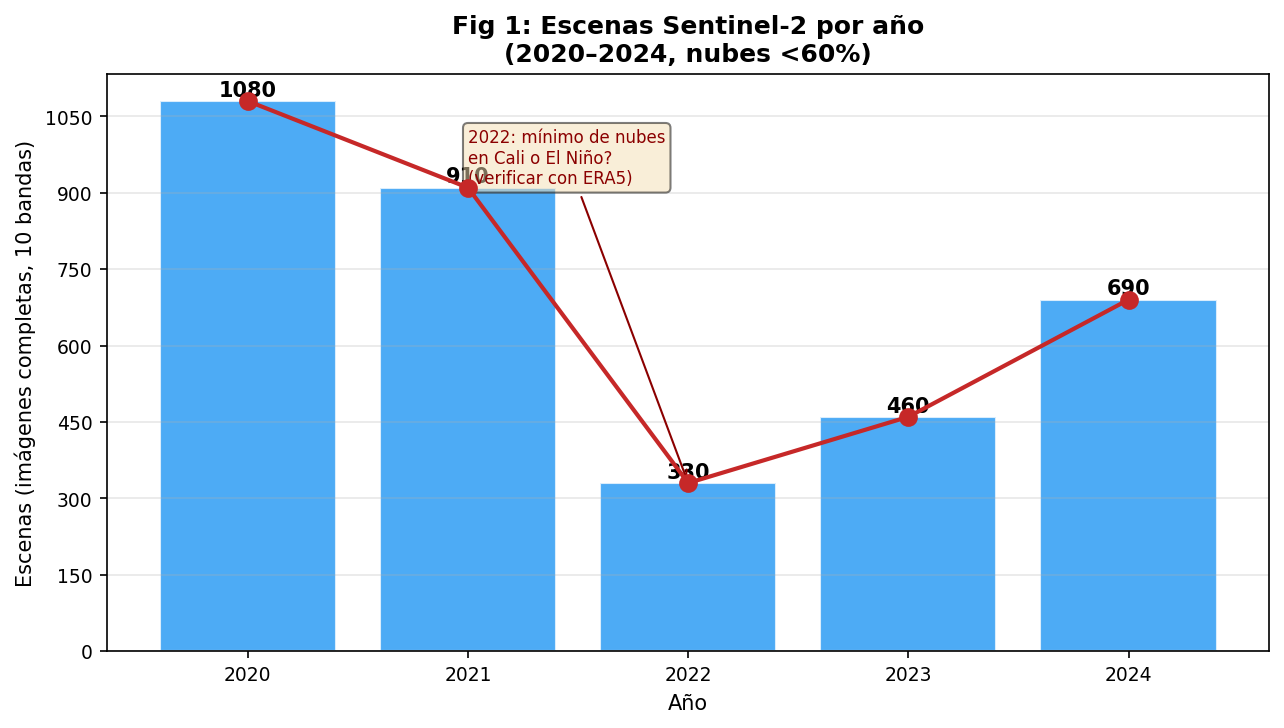

  💾 Guardado → 01_escenas_por_ano.png


PosixPath('/mnt/ssd_m2/almacenamiento/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/sentinel2/01_escenas_por_ano.png')

In [4]:
years = Counter()
for e in entries:
    dt = parse_scene_date(e["scene_id"])
    if dt:
        years[dt.year] += 1

df_years = pd.DataFrame({"año": list(years.keys()), "escenas": list(years.values())}).sort_values("año")

fig, ax1 = plt.subplots(figsize=(10, 5))
bars = ax1.bar(df_years["año"], df_years["escenas"], color="#2196F3", alpha=0.8, edgecolor="white")
ax1.plot(df_years["año"], df_years["escenas"], "o-", color="#C62828", linewidth=2, markersize=8, zorder=5)
for bar, val in zip(bars, df_years["escenas"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height()+2, str(val),
             ha="center", va="bottom", fontsize=10, fontweight="bold")
ax1.set_xlabel("Año")
ax1.set_ylabel("Escenas (imágenes completas, 10 bandas)")
ax1.set_title("Fig 1: Escenas Sentinel-2 por año\n(2020–2024, nubes <60%)", fontweight="bold")
ax1.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax1.set_xticks(df_years["año"])
ax1.annotate("2022: mínimo de nubes\nen Cali o El Niño?\n(verificar con ERA5)",
             xy=(2022, df_years[df_years["año"]==2022]["escenas"].values[0]),
             xytext=(2021, df_years["escenas"].max()*0.85),
             arrowprops=dict(arrowstyle="->", color="darkred"),
             fontsize=8, color="darkred", bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
ax1.grid(axis="y", alpha=0.3)

guardar_fig(fig, "01_escenas_por_ano")

### Fig 2 · Escenas por mes (apilado por año)

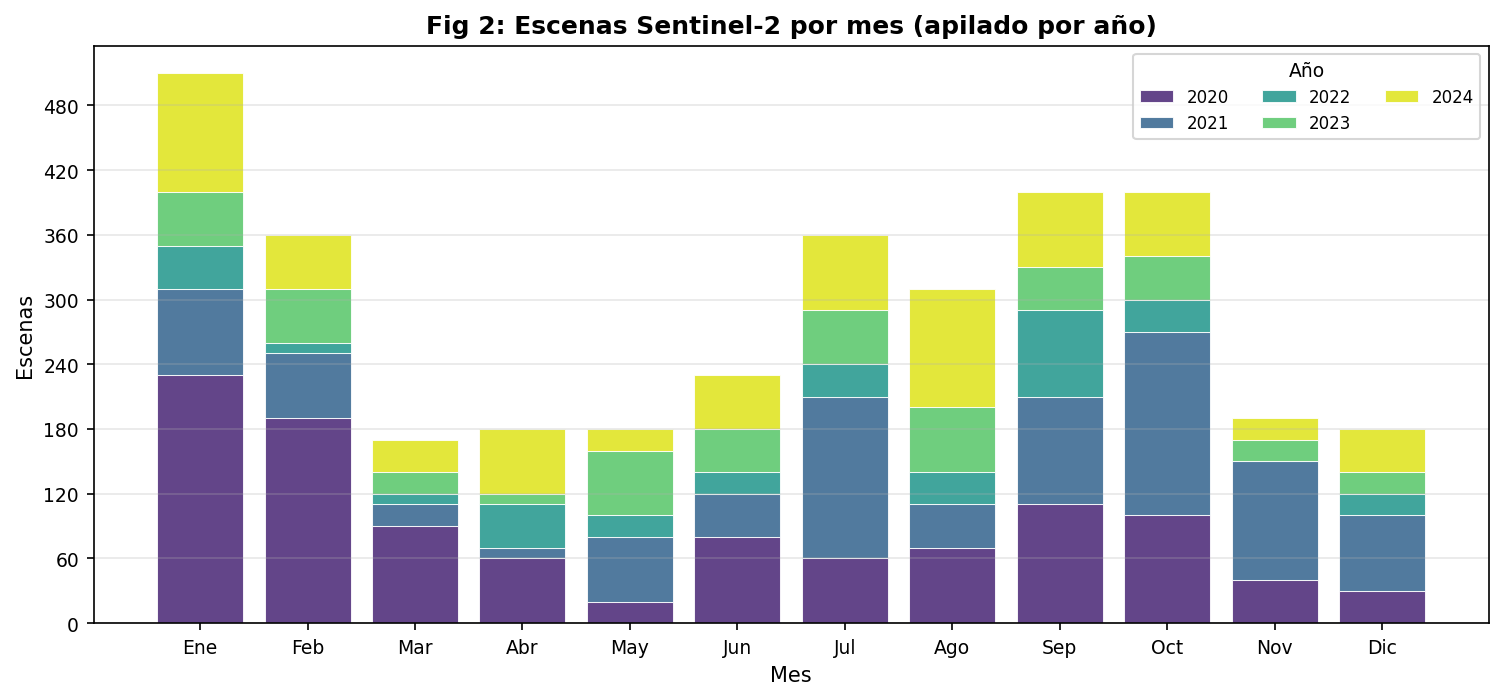

  💾 Guardado → 02_escenas_por_mes.png


PosixPath('/mnt/ssd_m2/almacenamiento/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/sentinel2/02_escenas_por_mes.png')

In [5]:
year_month = defaultdict(lambda: defaultdict(int))
all_years = set()
for e in entries:
    dt = parse_scene_date(e["scene_id"])
    if dt:
        year_month[dt.month][dt.year] += 1
        all_years.add(dt.year)
all_years = sorted(all_years)
months = range(1, 13)
month_names = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
data_mes = np.zeros((12, len(all_years)))
for mi, m in enumerate(months):
    for yi, y in enumerate(all_years):
        data_mes[mi, yi] = year_month[m].get(y, 0)

fig, ax = plt.subplots(figsize=(12, 5))
colors_years = plt.cm.viridis(np.linspace(0.1, 0.95, len(all_years)))
bottom = np.zeros(12)
for yi, y in enumerate(all_years):
    ax.bar(range(12), data_mes[:, yi], bottom=bottom, label=str(y),
           color=colors_years[yi], alpha=0.85, edgecolor="white", linewidth=0.5)
    bottom += data_mes[:, yi]
ax.set_xticks(range(12))
ax.set_xticklabels(month_names)
ax.set_xlabel("Mes")
ax.set_ylabel("Escenas")
ax.set_title("Fig 2: Escenas Sentinel-2 por mes (apilado por año)", fontweight="bold")
ax.legend(title="Año", ncol=3, fontsize=8, title_fontsize=9)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(axis="y", alpha=0.3)

guardar_fig(fig, "02_escenas_por_mes")

### Fig 3 · Heatmap de densidad temporal (año × mes)

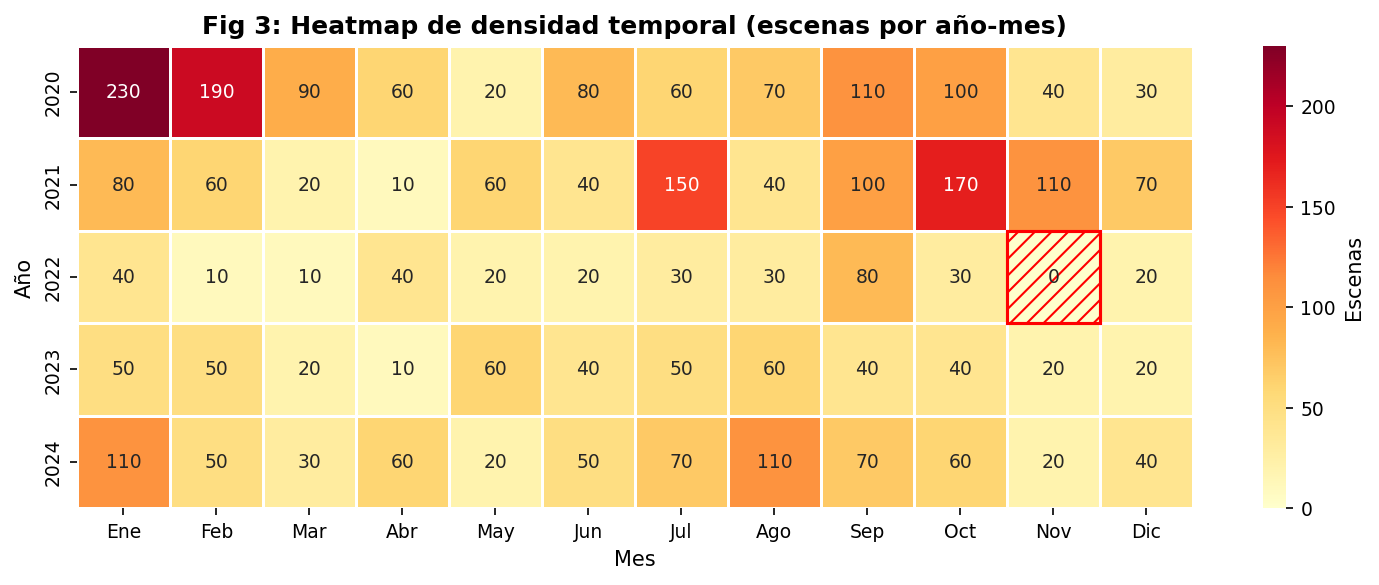

  💾 Guardado → 03_heatmap_temporal.png


PosixPath('/mnt/ssd_m2/almacenamiento/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/sentinel2/03_heatmap_temporal.png')

In [6]:
ym_heat = defaultdict(lambda: defaultdict(int))
for e in entries:
    dt = parse_scene_date(e["scene_id"])
    if dt:
        ym_heat[dt.year][dt.month] += 1
years_heat = sorted(ym_heat.keys())
data_heat = np.zeros((len(years_heat), 12))
for yi, y in enumerate(years_heat):
    for m in range(1, 13):
        data_heat[yi, m-1] = ym_heat[y].get(m, 0)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(data_heat, annot=True, fmt=".0f", cmap="YlOrRd",
            xticklabels=["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"],
            yticklabels=years_heat,
            cbar_kws={"label": "Escenas"}, linewidths=0.5, linecolor="white",
            vmin=0, vmax=data_heat.max(), ax=ax)
ax.set_title("Fig 3: Heatmap de densidad temporal (escenas por año-mes)", fontweight="bold")
ax.set_xlabel("Mes")
ax.set_ylabel("Año")
for yi in range(len(years_heat)):
    for mi in range(12):
        if data_heat[yi, mi] == 0:
            ax.add_patch(plt.Rectangle((mi, yi), 1, 1, fill=False,
                                       edgecolor="red", lw=1.5, hatch="///"))

guardar_fig(fig, "03_heatmap_temporal")

---
## Sección 2 — Cobertura espacial
### Fig 4 · Distribución por tile MGRS y por satélite

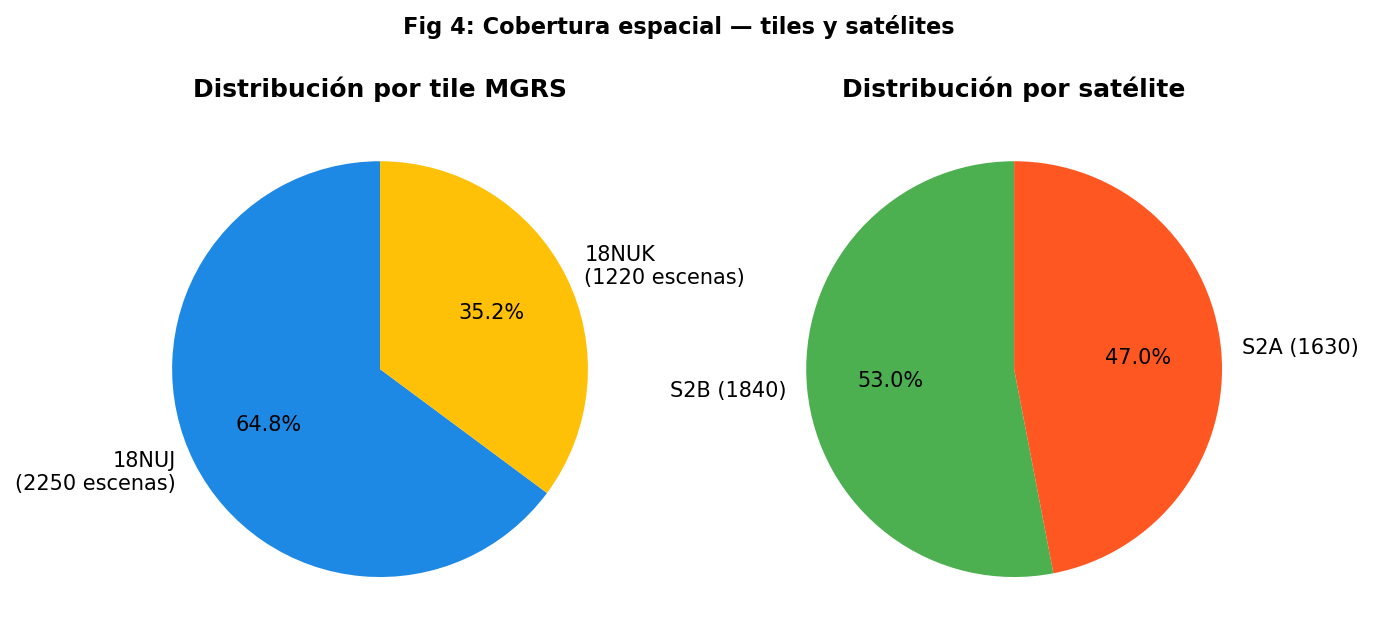

  💾 Guardado → 04_tiles_satelites.png


PosixPath('/mnt/ssd_m2/almacenamiento/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/sentinel2/04_tiles_satelites.png')

In [7]:
tiles = Counter()
sats  = Counter()
for e in entries:
    tiles[parse_tile(e["scene_id"])] += 1
    sats[parse_sat(e["scene_id"])]   += 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))

tile_labels = [f"{t}\n({c} escenas)" for t, c in tiles.items()]
ax1.pie(tiles.values(), labels=tile_labels, autopct="%1.1f%%",
        colors=["#1E88E5", "#FFC107"], startangle=90, textprops={"fontsize": 10})
ax1.set_title("Distribución por tile MGRS", fontweight="bold")

sat_labels = [f"{s} ({c})" for s, c in sats.items()]
ax2.pie(sats.values(), labels=sat_labels, autopct="%1.1f%%",
        colors=["#4CAF50", "#FF5722"], startangle=90, textprops={"fontsize": 10})
ax2.set_title("Distribución por satélite", fontweight="bold")
fig.suptitle("Fig 4: Cobertura espacial — tiles y satélites", fontweight="bold", y=1.02)

guardar_fig(fig, "04_tiles_satelites")

### Fig 5 · Mapa de cobertura espacial (tiles MGRS + estaciones DAGMA)

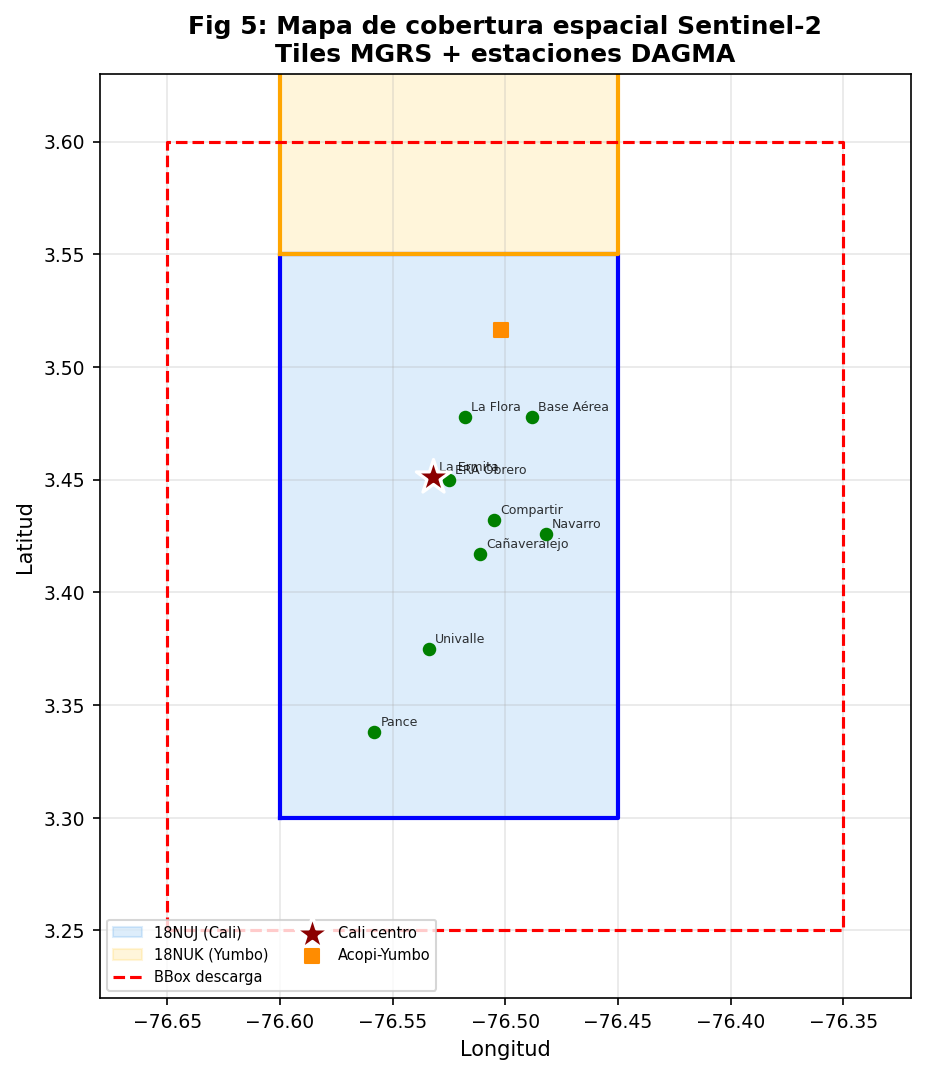

  💾 Guardado → 05_mapa_cobertura.png


PosixPath('/mnt/ssd_m2/almacenamiento/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/sentinel2/05_mapa_cobertura.png')

In [8]:
tile_18NUJ_lon = [-76.60, -76.45, -76.45, -76.60, -76.60]
tile_18NUJ_lat = [3.30,   3.30,   3.55,   3.55,   3.30  ]
tile_18NUK_lon = [-76.60, -76.45, -76.45, -76.60, -76.60]
tile_18NUK_lat = [3.55,   3.55,   3.70,   3.70,   3.55  ]

fig, ax = plt.subplots(figsize=(9, 8))
ax.fill(tile_18NUJ_lon, tile_18NUJ_lat, alpha=0.15, color="#1E88E5", label="18NUJ (Cali)")
ax.fill(tile_18NUK_lon, tile_18NUK_lat, alpha=0.15, color="#FFC107", label="18NUK (Yumbo)")
ax.plot(tile_18NUJ_lon, tile_18NUJ_lat, "b-",     linewidth=2)
ax.plot(tile_18NUK_lon, tile_18NUK_lat, "orange", linewidth=2)

bbox_lon = [-76.65, -76.35, -76.35, -76.65, -76.65]
bbox_lat = [3.25,   3.25,   3.60,   3.60,   3.25  ]
ax.plot(bbox_lon, bbox_lat, "r--", linewidth=1.5, label="BBox descarga")

ax.scatter(-76.532, 3.451, marker="*", s=300, color="darkred", zorder=10,
           label="Cali centro", edgecolors="white", linewidth=1.5)

dagma_stations = {
    "Base Aérea"   : (-76.488, 3.478), "Cañaveralejo": (-76.511, 3.417),
    "Compartir"    : (-76.505, 3.432), "ERA Obrero"  : (-76.525, 3.450),
    "La Ermita"    : (-76.532, 3.451), "La Flora"    : (-76.518, 3.478),
    "Pance"        : (-76.558, 3.338), "Navarro"     : (-76.482, 3.426),
    "Univalle"     : (-76.534, 3.375),
}
for name, (lon, lat) in dagma_stations.items():
    ax.scatter(lon, lat, marker="o", s=30, color="green", zorder=8)
    ax.annotate(name, (lon, lat), textcoords="offset points", xytext=(3, 3),
                fontsize=6, alpha=0.8)

ax.scatter(-76.5019, 3.5164, marker="s", s=50, color="darkorange", zorder=9, label="Acopi-Yumbo")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.set_title("Fig 5: Mapa de cobertura espacial Sentinel-2\nTiles MGRS + estaciones DAGMA",
             fontweight="bold")
ax.legend(loc="lower left", fontsize=7, ncol=2)
ax.set_xlim(-76.68, -76.32)
ax.set_ylim(3.22,   3.63)
ax.grid(alpha=0.3)
ax.set_aspect("equal")

guardar_fig(fig, "05_mapa_cobertura")

---
## Sección 3 — Estadísticas de bandas
### Muestreo de escenas y lectura de GeoTIFFs

In [9]:
def sample_scenes(entries, n=N_SAMPLE_SCENES):
    scene_ids = list(set(e["scene_id"] for e in entries))
    random.seed(RANDOM_SEED)
    return random.sample(scene_ids, min(n, len(scene_ids)))

def read_band_preview(scene_dir: Path, banda: str, ov_level=OVERVIEW_LEVEL):
    tif = scene_dir / f"{banda}.tif"
    if not tif.exists():
        return None
    try:
        with rasterio.open(tif) as src:
            if ov_level and src.overviews(1):
                available = [o for o in src.overviews(1) if o <= ov_level]
                level = max(available) if available else None
                if level:
                    data = src.read(1, out_shape=(src.height // level, src.width // level))
                else:
                    data = src.read(1)
            else:
                data = src.read(1)
            valid = data[(data > 0) & (data < 20000)]
            return valid if len(valid) >= 100 else None
    except Exception as ex:
        print(f"    ⚠ Error leyendo {tif}: {ex}")
        return None

def read_ndvi(scene_dir: Path, ov_level=OVERVIEW_LEVEL):
    try:
        red_path = scene_dir / "B04.tif"
        nir_path = scene_dir / "B08.tif"
        if not red_path.exists() or not nir_path.exists():
            return None, None
        with rasterio.open(red_path) as r, rasterio.open(nir_path) as n:
            if ov_level and r.overviews(1) and n.overviews(1):
                level_r = max([o for o in r.overviews(1) if o <= ov_level])
                level_n = max([o for o in n.overviews(1) if o <= ov_level])
                red = r.read(1, out_shape=(r.height // level_r, r.width // level_r)).astype(np.float32)
                nir = n.read(1, out_shape=(n.height // level_n, n.width // level_n)).astype(np.float32)
            else:
                red = r.read(1).astype(np.float32)
                nir = n.read(1).astype(np.float32)
        red /= 10000.0
        nir /= 10000.0
        mask  = (red > 0) & (red < 1.0) & (nir > 0) & (nir < 1.0)
        ndvi  = np.zeros_like(red)
        denom = nir + red
        valid = mask & (denom > 0.001)
        ndvi[valid] = (nir[valid] - red[valid]) / denom[valid]
        ndvi_valid = ndvi[valid]
        return (ndvi, ndvi_valid) if len(ndvi_valid) >= 100 else (None, None)
    except Exception:
        return None, None

# ── Muestreo ──
scene_ids = sample_scenes(entries)
scene_dir_map = {}
for e in entries:
    sid = e["scene_id"]
    if sid in scene_ids and sid not in scene_dir_map:
        scene_dir_map[sid] = Path(e["file"]).parent

all_bands           = {b: [] for b in BANDAS}
completeness        = []
ndvi_values         = []
ndvi_by_month       = defaultdict(list)

for sid in tqdm(scene_dir_map, desc="Muestreando escenas"):
    scene_dir = scene_dir_map[sid]
    dt        = parse_scene_date(sid)
    month_key = dt.strftime("%Y-%m") if dt else None
    pixel_counts = []
    for banda in BANDAS:
        vals = read_band_preview(scene_dir, banda)
        if vals is not None:
            all_bands[banda].append(vals)
            pixel_counts.append(len(vals))
    if pixel_counts:
        max_pix = max(pixel_counts)
        completeness.append({
            "scene_id"           : sid,
            "date"               : dt,
            "total_valid_pixels" : int(np.sum(pixel_counts)),
            "fraccion_vs_max"    : np.mean(pixel_counts) / max_pix if max_pix > 0 else 0,
        })
    ndvi_arr, ndvi_valid = read_ndvi(scene_dir)
    if ndvi_valid is not None and len(ndvi_valid) > 0:
        ndvi_values.append(ndvi_valid)
        if month_key:
            ndvi_by_month[month_key].append(ndvi_valid)

total_pixels = sum(len(v) for b in BANDAS for v in all_bands[b] if v is not None)
print(f"\nEscenas muestreadas : {len(completeness)}")
print(f"Píxeles analizados  : {total_pixels:,}")

Muestreando escenas:   0%|          | 0/40 [00:00<?, ?it/s]


Escenas muestreadas : 40
Píxeles analizados  : 1,084,257,814


### Fig 6 · Boxplots de reflectancia por banda

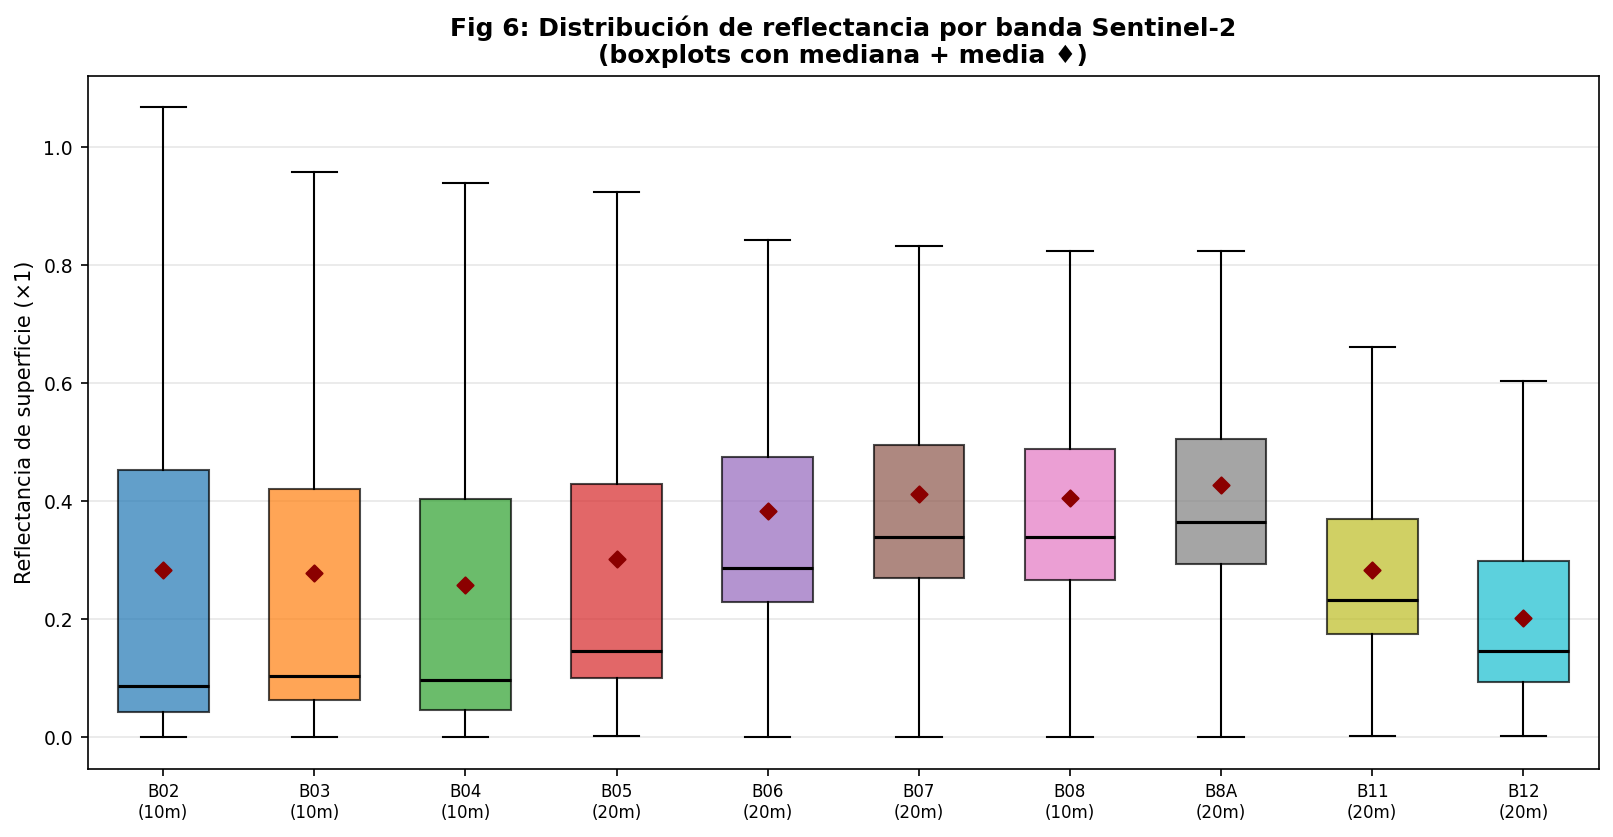

  💾 Guardado → 06_boxplot_bandas.png


PosixPath('/mnt/ssd_m2/almacenamiento/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/sentinel2/06_boxplot_bandas.png')

In [10]:
fig, ax = plt.subplots(figsize=(13, 6))
data_to_plot = []
positions    = []
labels       = []
for i, b in enumerate(BANDAS):
    if all_bands[b]:
        vals = np.concatenate([v / 10000.0 for v in all_bands[b]], axis=0)
        if len(vals) > 50000:
            vals = np.random.choice(vals, 50000, replace=False)
        data_to_plot.append(vals)
        positions.append(i + 1)
        labels.append(f"{b}\n({BANDA_RES[b]})")

bp = ax.boxplot(data_to_plot, positions=positions, widths=0.6, patch_artist=True,
                showfliers=False, medianprops={"color": "black", "linewidth": 1.5})
for i, box in enumerate(bp["boxes"]):
    box.set_facecolor(COLORS[i])
    box.set_alpha(0.7)
for i, vals in enumerate(data_to_plot):
    ax.scatter(positions[i], np.mean(vals), marker="D", color="darkred", s=30, zorder=10)
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("Reflectancia de superficie (×1)")
ax.set_title("Fig 6: Distribución de reflectancia por banda Sentinel-2\n(boxplots con mediana + media ♦)",
             fontweight="bold")
ax.grid(axis="y", alpha=0.3)

guardar_fig(fig, "06_boxplot_bandas")

### Fig 7 · Histogramas de reflectancia por banda

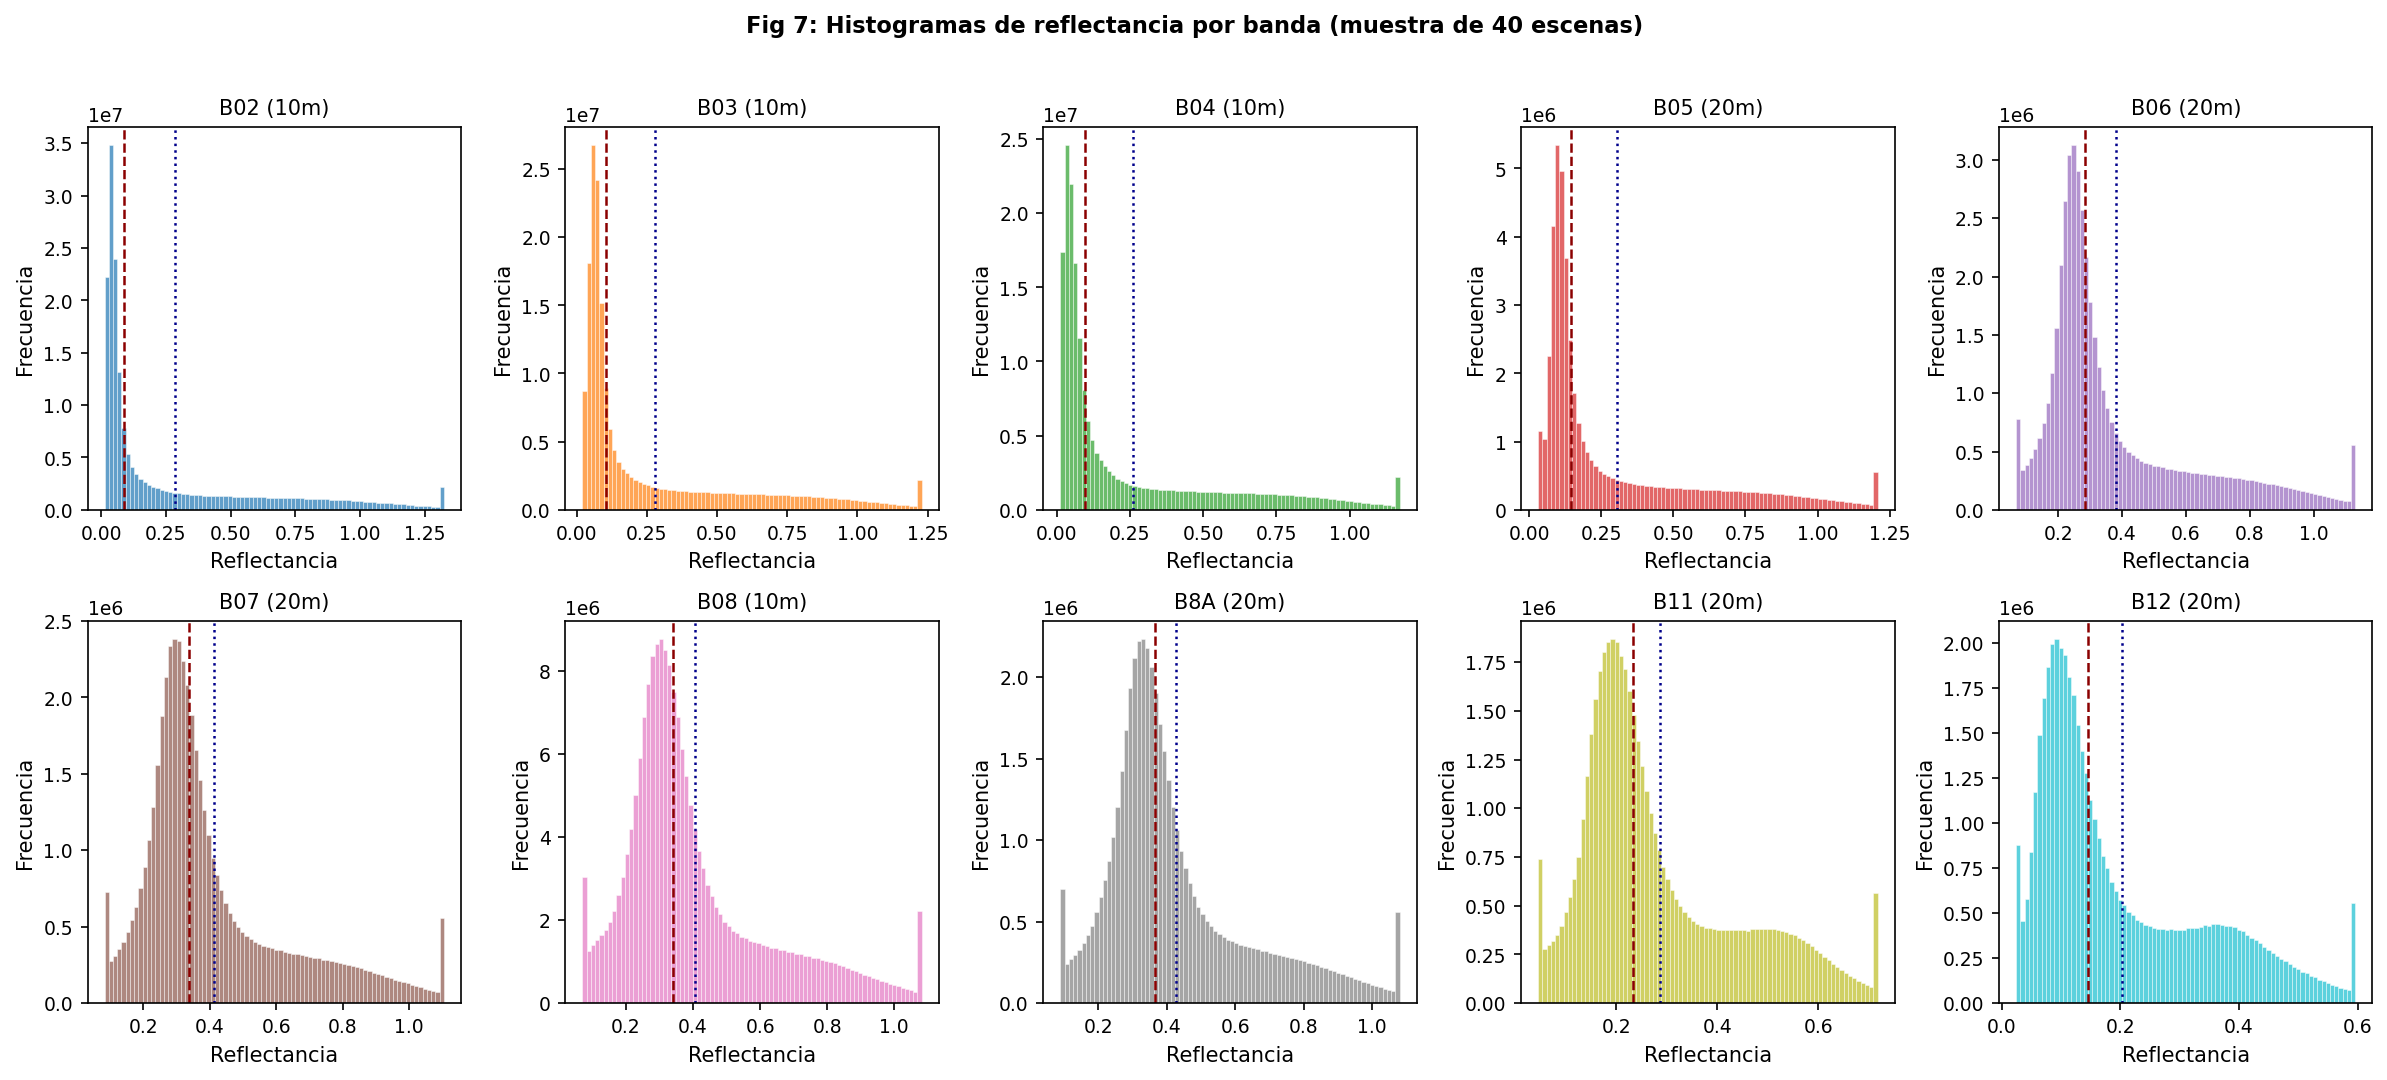

  💾 Guardado → 07_histogramas_bandas.png


PosixPath('/mnt/ssd_m2/almacenamiento/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/sentinel2/07_histogramas_bandas.png')

In [11]:
n_bands = len([b for b in BANDAS if all_bands[b]])
cols    = 5
rows    = (n_bands + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 3.5 * rows))
axes = axes.flatten() if n_bands > 1 else [axes]

for i, b in enumerate(BANDAS):
    ax = axes[i]
    if all_bands[b]:
        vals    = np.concatenate([v / 10000.0 for v in all_bands[b]], axis=0)
        lo, hi  = np.percentile(vals, [1, 99])
        ax.hist(np.clip(vals, lo, hi), bins=80, color=COLORS[i], alpha=0.7,
                edgecolor="white", linewidth=0.3)
        ax.axvline(np.median(vals), color="darkred",  linestyle="--", linewidth=1.2)
        ax.axvline(np.mean(vals),   color="darkblue", linestyle=":",  linewidth=1.2)
    ax.set_title(f"{b} ({BANDA_RES[b]})", fontsize=10)
    ax.set_xlabel("Reflectancia")
    ax.set_ylabel("Frecuencia")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

n_sampled = len([v for v in all_bands[list(all_bands.keys())[0]] if v is not None])
fig.suptitle(f"Fig 7: Histogramas de reflectancia por banda (muestra de {n_sampled} escenas)",
             fontweight="bold", y=1.02)
plt.tight_layout()

guardar_fig(fig, "07_histogramas_bandas")

### Fig 8 · Matriz de correlación de Pearson entre bandas

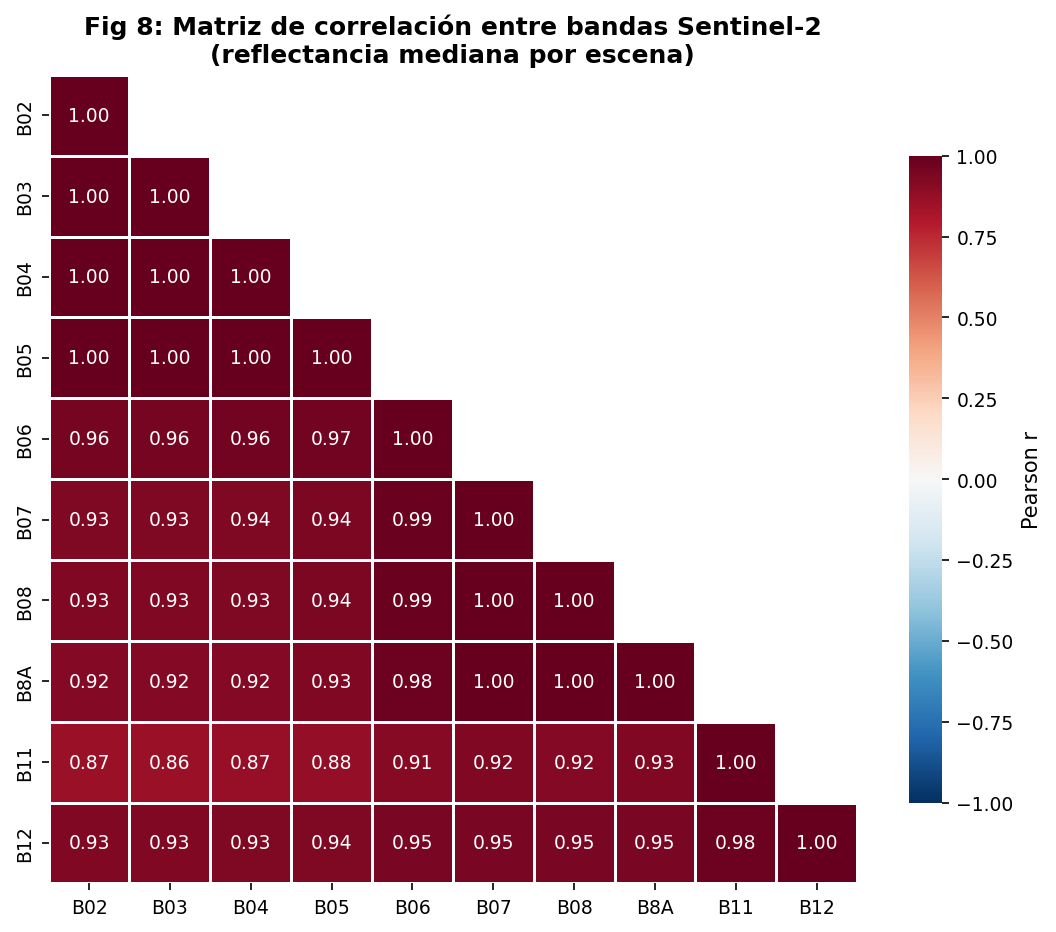

  💾 Guardado → 08_correlacion_bandas.png


In [12]:
n_scenes = min(len(v) for v in all_bands.values() if v)

if n_scenes == 0:
    print("⚠ No hay datos suficientes para la matriz de correlación")
else:
    data_corr  = np.zeros((n_scenes, len(BANDAS)))
    valid_mask = np.ones(n_scenes, dtype=bool)
    for bi, b in enumerate(BANDAS):
        for si, vals in enumerate(all_bands[b][:n_scenes]):
            if vals is not None and len(vals) > 0:
                data_corr[si, bi] = np.median(vals) / 10000.0
            else:
                valid_mask[si] = False
    data_corr = data_corr[valid_mask]

    corr = np.corrcoef(data_corr.T)
    fig, ax = plt.subplots(figsize=(9, 7))
    mask_upper = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                vmin=-1, vmax=1, xticklabels=BANDAS, yticklabels=BANDAS,
                mask=mask_upper, linewidths=0.5, square=True,
                cbar_kws={"label": "Pearson r", "shrink": 0.8}, ax=ax)
    ax.set_title("Fig 8: Matriz de correlación entre bandas Sentinel-2\n(reflectancia mediana por escena)",
                 fontweight="bold")

    guardar_fig(fig, "08_correlacion_bandas")

---
## Sección 4 — NDVI
### Fig 9 · Histograma NDVI global y categorías de cobertura

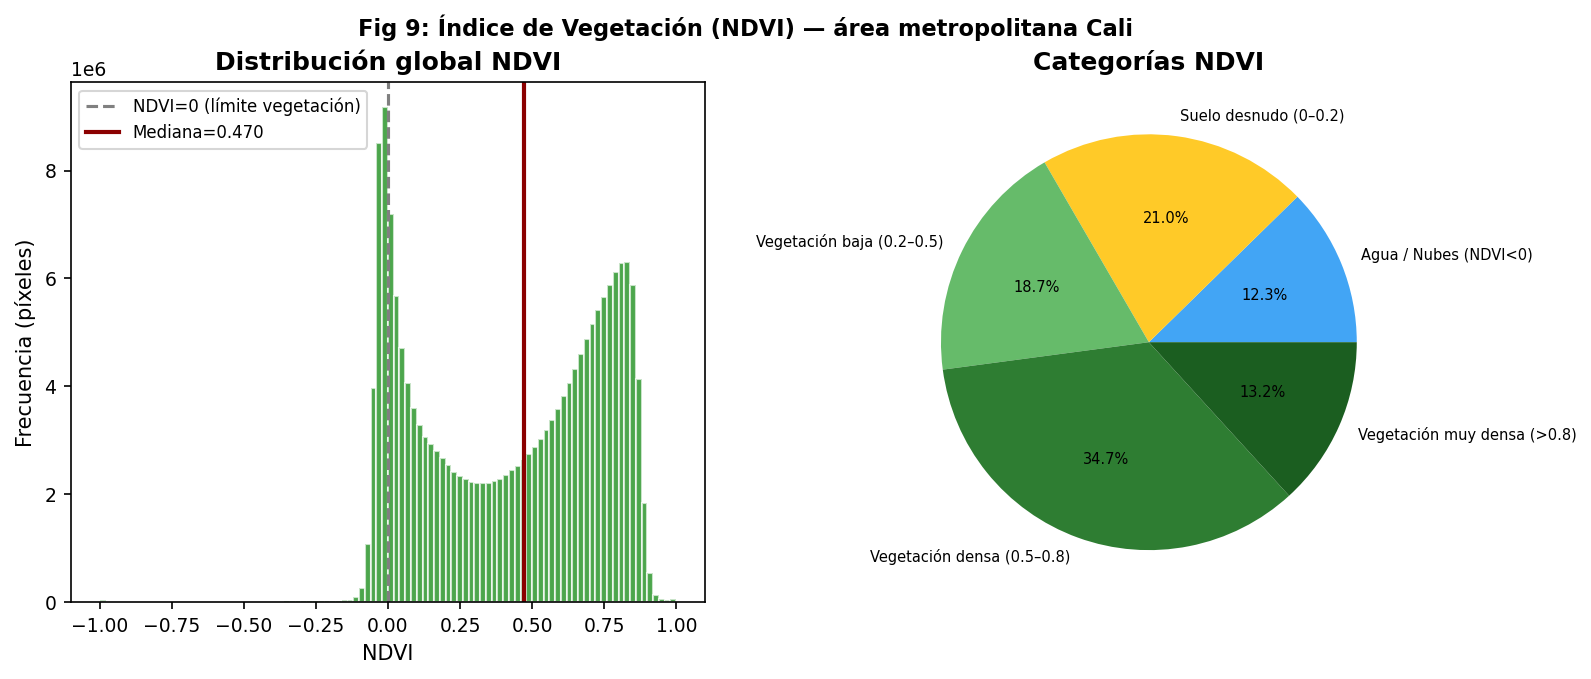

  💾 Guardado → 09_ndvi_histograma.png


In [13]:
if not ndvi_values:
    print("⚠ No se obtuvieron valores NDVI del muestreo")
else:
    all_ndvi = np.concatenate(ndvi_values)
    all_ndvi = all_ndvi[(all_ndvi > -1) & (all_ndvi < 1)]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

    ax1.hist(all_ndvi, bins=100, color="green", alpha=0.7, edgecolor="white")
    ax1.axvline(0, color="gray", linestyle="--", label="NDVI=0 (límite vegetación)")
    ax1.axvline(np.median(all_ndvi), color="darkred", linestyle="-", linewidth=2,
                label=f"Mediana={np.median(all_ndvi):.3f}")
    ax1.set_xlabel("NDVI")
    ax1.set_ylabel("Frecuencia (píxeles)")
    ax1.set_title("Distribución global NDVI", fontweight="bold")
    ax1.legend(fontsize=8)

    categories = {
        "Agua / Nubes (NDVI<0)"         : np.sum(all_ndvi < 0),
        "Suelo desnudo (0–0.2)"         : np.sum((all_ndvi >= 0) & (all_ndvi < 0.2)),
        "Vegetación baja (0.2–0.5)"     : np.sum((all_ndvi >= 0.2) & (all_ndvi < 0.5)),
        "Vegetación densa (0.5–0.8)"    : np.sum((all_ndvi >= 0.5) & (all_ndvi < 0.8)),
        "Vegetación muy densa (>0.8)"   : np.sum(all_ndvi >= 0.8),
    }
    colors_pie = ["#42A5F5", "#FFCA28", "#66BB6A", "#2E7D32", "#1B5E20"]
    ax2.pie(categories.values(), labels=categories.keys(), autopct="%1.1f%%",
            colors=colors_pie, textprops={"fontsize": 7})
    ax2.set_title("Categorías NDVI", fontweight="bold")
    fig.suptitle("Fig 9: Índice de Vegetación (NDVI) — área metropolitana Cali",
                 fontweight="bold")

    guardar_fig(fig, "09_ndvi_histograma")

### Fig 10 · Serie temporal NDVI — mediana mensual

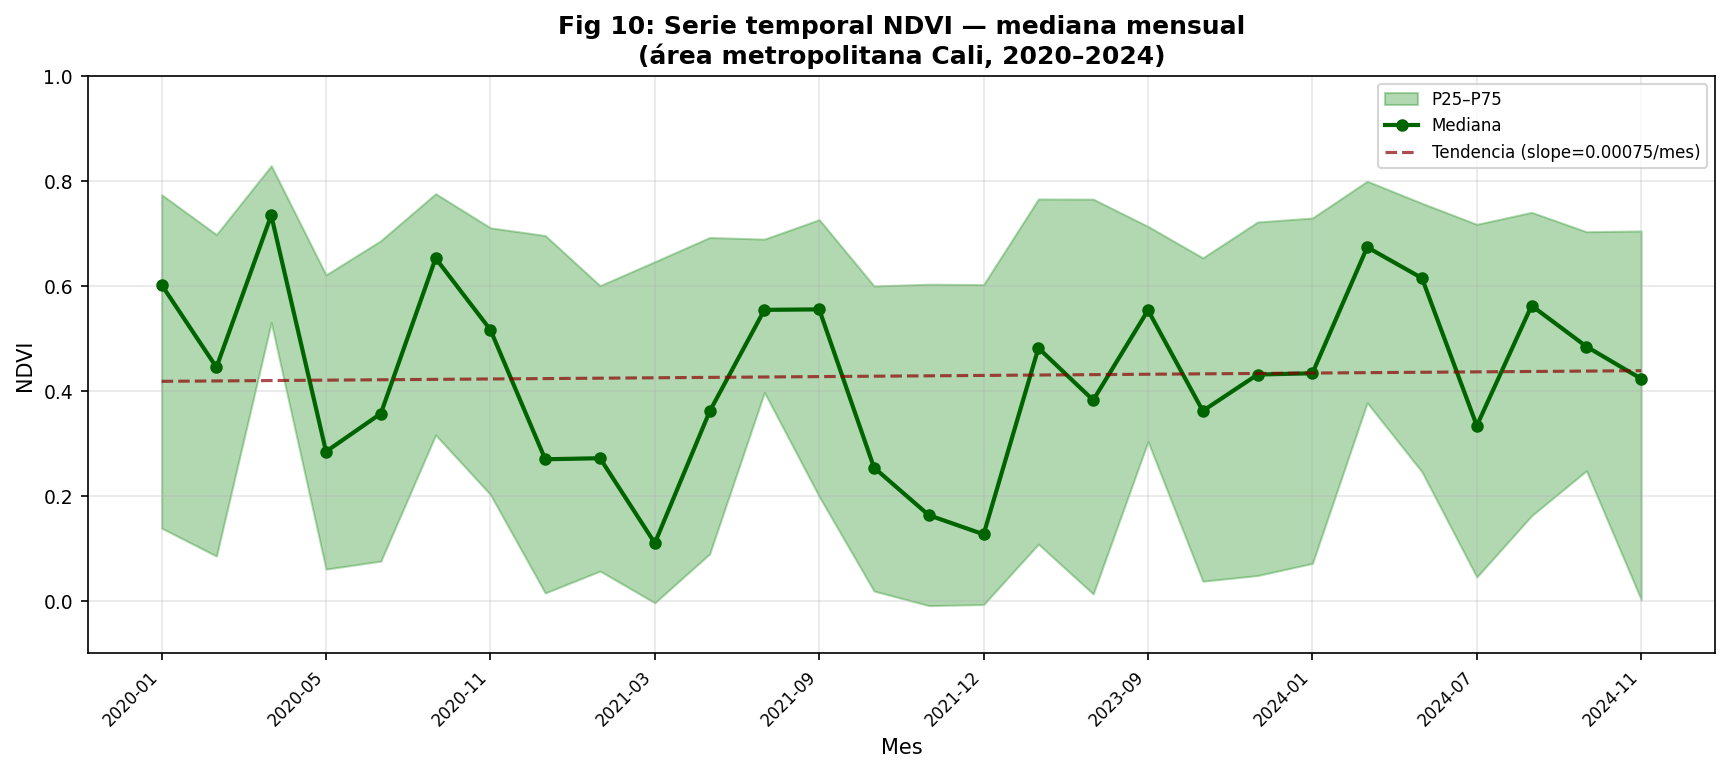

  💾 Guardado → 10_ndvi_serie_temporal.png


In [14]:
if not ndvi_by_month:
    print("⚠ No hay datos NDVI mensuales")
else:
    months_ts = sorted(ndvi_by_month.keys())
    medians, p25_ts, p75_ts = [], [], []
    for m in months_ts:
        vals = np.concatenate([v for v in ndvi_by_month[m]])
        vals = vals[(vals > -1) & (vals < 1)]
        medians.append(np.median(vals))
        p25_ts.append(np.percentile(vals, 25))
        p75_ts.append(np.percentile(vals, 75))

    fig, ax = plt.subplots(figsize=(14, 5))
    x = range(len(months_ts))
    ax.fill_between(x, p25_ts, p75_ts, alpha=0.3, color="green", label="P25–P75")
    ax.plot(x, medians, "o-", color="darkgreen", linewidth=2, markersize=5, label="Mediana")
    z     = np.polyfit(x, medians, 1)
    trend = np.poly1d(z)
    ax.plot(x, trend(x), "--", color="darkred", linewidth=1.5, alpha=0.7,
            label=f"Tendencia (slope={z[0]:.5f}/mes)")
    tick_positions = list(x)[::3]
    tick_labels    = [months_ts[i] for i in range(0, len(months_ts), 3)]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)
    ax.set_xlabel("Mes")
    ax.set_ylabel("NDVI")
    ax.set_title("Fig 10: Serie temporal NDVI — mediana mensual\n(área metropolitana Cali, 2020–2024)",
                 fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_ylim(-0.1, 1.0)

    guardar_fig(fig, "10_ndvi_serie_temporal")

---
## Sección 5 — Completitud de píxeles
### Fig 11 · Completitud de píxeles Sentinel-2

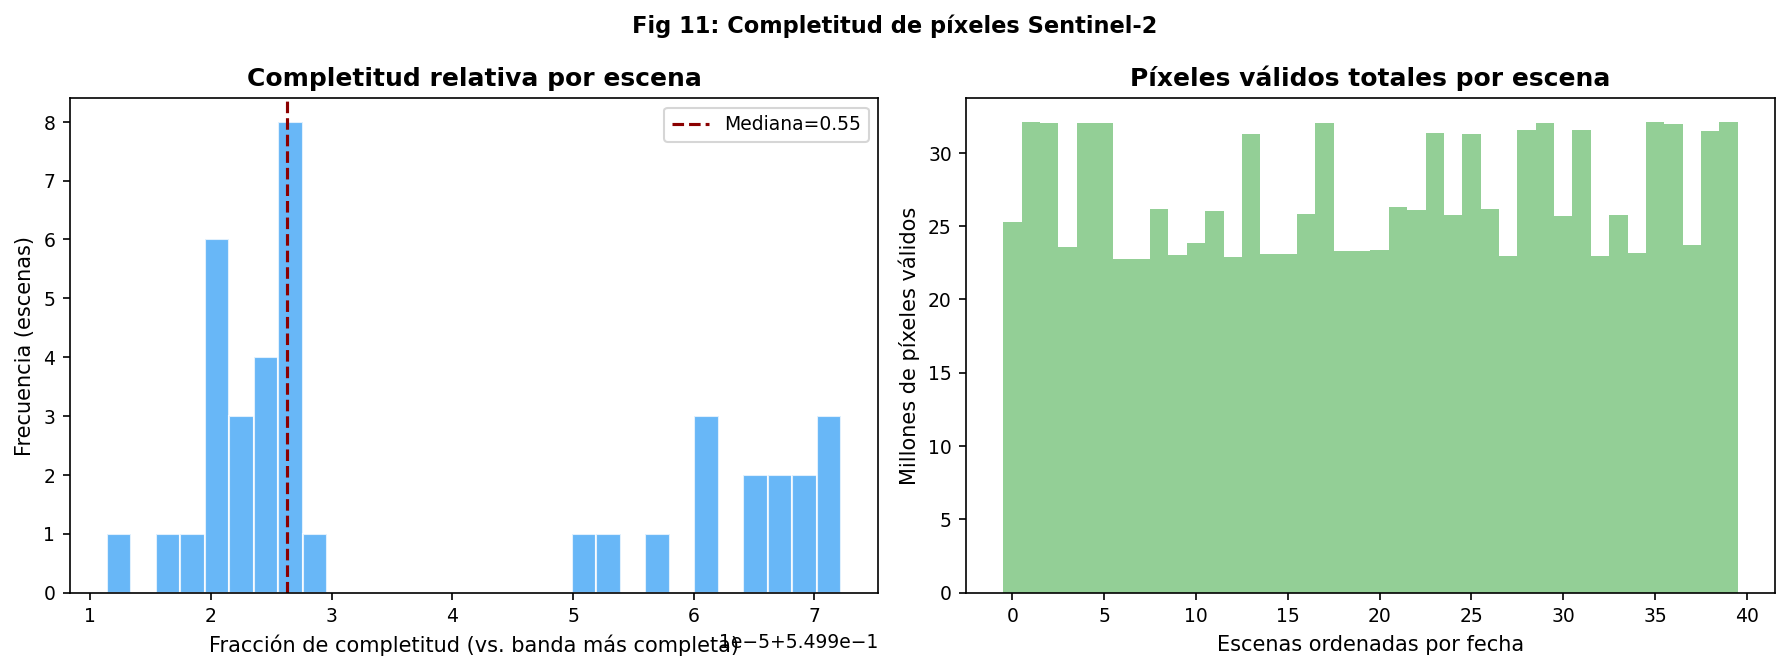

  💾 Guardado → 11_completitud_pixeles.png


In [15]:
if not completeness:
    print("⚠ No hay datos de completitud")
else:
    df_comp = pd.DataFrame(completeness)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

    ax1.hist(df_comp["fraccion_vs_max"], bins=30, color="#42A5F5", edgecolor="white", alpha=0.8)
    ax1.axvline(np.median(df_comp["fraccion_vs_max"]), color="darkred", linestyle="--",
                label=f"Mediana={np.median(df_comp['fraccion_vs_max']):.2f}")
    ax1.set_xlabel("Fracción de completitud (vs. banda más completa)")
    ax1.set_ylabel("Frecuencia (escenas)")
    ax1.set_title("Completitud relativa por escena", fontweight="bold")
    ax1.legend()

    df_sorted = df_comp.sort_values("date")
    ax2.bar(range(len(df_sorted)), df_sorted["total_valid_pixels"] / 1e6,
            color="#66BB6A", alpha=0.7, width=1.0)
    ax2.set_xlabel("Escenas ordenadas por fecha")
    ax2.set_ylabel("Millones de píxeles válidos")
    ax2.set_title("Píxeles válidos totales por escena", fontweight="bold")

    fig.suptitle("Fig 11: Completitud de píxeles Sentinel-2", fontweight="bold")
    plt.tight_layout()

    guardar_fig(fig, "11_completitud_pixeles")

### Fig 12 · Escenas por año y tile (18NUJ vs 18NUK)

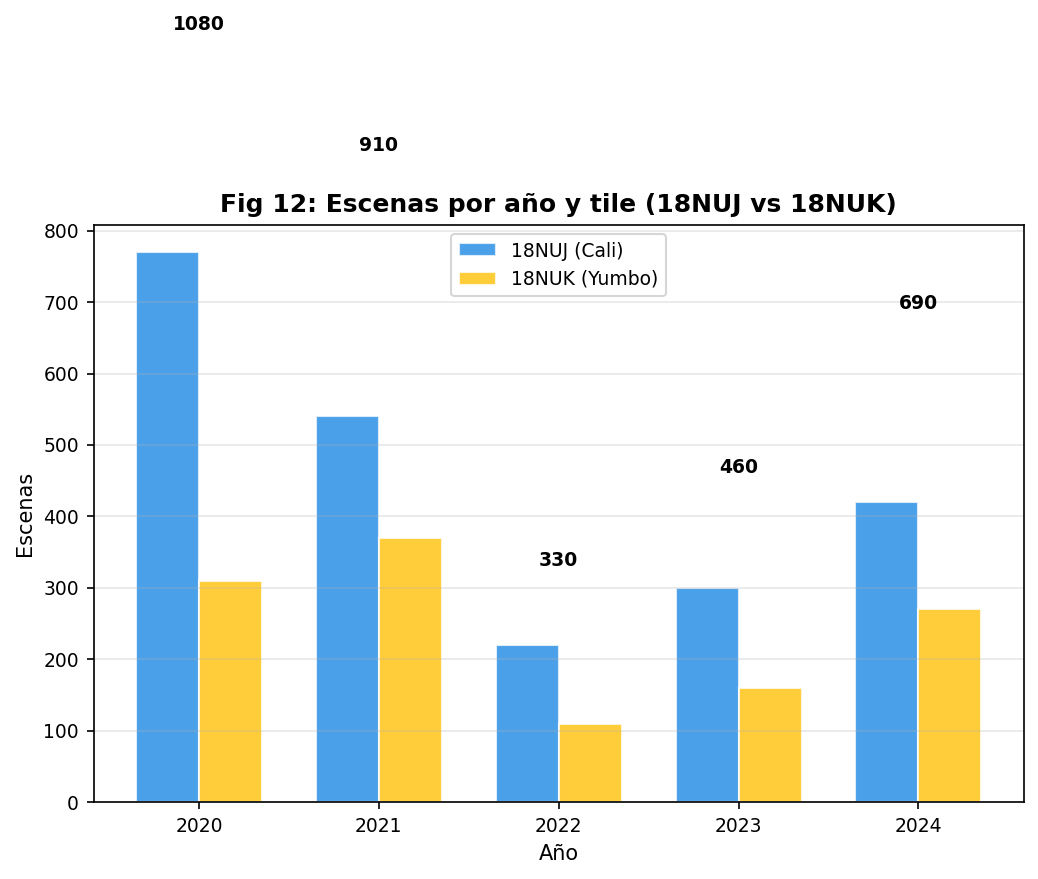

  💾 Guardado → 12_escenas_por_tile_ano.png


PosixPath('/mnt/ssd_m2/almacenamiento/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/sentinel2/12_escenas_por_tile_ano.png')

In [16]:
year_tile = defaultdict(lambda: defaultdict(int))
for e in entries:
    dt   = parse_scene_date(e["scene_id"])
    tile = parse_tile(e["scene_id"])
    if dt and tile in ("18NUJ", "18NUK"):
        year_tile[dt.year][tile] += 1

years_tile = sorted(year_tile.keys())
fig, ax    = plt.subplots(figsize=(8, 5))
x          = np.arange(len(years_tile))
width      = 0.35
nu18j = [year_tile[y].get("18NUJ", 0) for y in years_tile]
nu18k = [year_tile[y].get("18NUK", 0) for y in years_tile]

ax.bar(x - width/2, nu18j, width, label="18NUJ (Cali)",  color="#1E88E5", alpha=0.8, edgecolor="white")
ax.bar(x + width/2, nu18k, width, label="18NUK (Yumbo)", color="#FFC107", alpha=0.8, edgecolor="white")
for i, (v1, v2) in enumerate(zip(nu18j, nu18k)):
    ax.text(i, v1 + v2 + 1, str(v1 + v2), ha="center", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(years_tile)
ax.set_xlabel("Año")
ax.set_ylabel("Escenas")
ax.set_title("Fig 12: Escenas por año y tile (18NUJ vs 18NUK)", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)

guardar_fig(fig, "12_escenas_por_tile_ano")

---
## Sección 6 — Resumen estadístico

In [17]:
stats_list = []
for b in BANDAS:
    if all_bands[b]:
        vals = np.concatenate([v / 10000.0 for v in all_bands[b]], axis=0)
        stats_list.append({
            "Banda"      : f"{b} ({BANDA_RES[b]})",
            "Descripción": BANDA_LABELS.get(b, ""),
            "N píxeles"  : len(vals),
            "Media"      : np.mean(vals),
            "Mediana"    : np.median(vals),
            "Std"        : np.std(vals),
            "P1"         : np.percentile(vals, 1),
            "P99"        : np.percentile(vals, 99),
            "CV"         : np.std(vals) / (np.mean(vals) + 1e-10),
        })

df_stats = pd.DataFrame(stats_list)
csv_path = OUT_DIR / "estadisticas_bandas.csv"
df_stats.to_csv(csv_path, index=False)
print(f"✓ CSV exportado → {csv_path.name}")

df_stats.style \
    .format({"Media": "{:.4f}", "Mediana": "{:.4f}", "Std": "{:.4f}",
             "P1": "{:.4f}", "P99": "{:.4f}", "CV": "{:.3f}",
             "N píxeles": "{:,.0f}"}) \
    .background_gradient(subset=["Media", "Std", "CV"], cmap="Blues")

✓ CSV exportado → estadisticas_bandas.csv


,Banda,Descripción,N píxeles,Media,Mediana,Std,P1,P99,CV
0,B02 (10m),Blue (490 nm),"197,159,251",0.2838,0.0870,0.3501,0.0130,1.3240,1.234
1,B03 (10m),Green (560 nm),"197,160,603",0.2802,0.1050,0.3179,0.0209,1.2292,1.134
2,B04 (10m),Red (665 nm),"197,160,606",0.2599,0.0962,0.3071,0.0128,1.1701,1.182
3,B05 (20m),RedEdge 1 (705 nm),"49,269,458",0.3035,0.1460,0.3012,0.0314,1.2080,0.992
4,B06 (20m),RedEdge 2 (740 nm),"49,269,458",0.3823,0.2856,0.2431,0.0688,1.1301,0.636
5,B07 (20m),RedEdge 3 (783 nm),"49,269,458",0.4123,0.3384,0.2257,0.0835,1.1041,0.547
6,B08 (10m),NIR (842 nm),"197,160,606",0.4053,0.3396,0.2216,0.0699,1.0818,0.547
7,B8A (20m),NIR narrow (865 nm),"49,269,458",0.4277,0.3656,0.2138,0.0889,1.0799,0.500
8,B11 (20m),SWIR 1 (1610 nm),"49,269,458",0.2863,0.2340,0.1587,0.0460,0.7172,0.554
9,B12 (20m),SWIR 2 (2190 nm),"49,269,458",0.2022,0.1460,0.1432,0.0244,0.5964,0.708


In [18]:
# ── Reporte TXT ────────────────────────────────────────
report_lines = [
    "=" * 70,
    "GeoVision-CLIP Cali — EDA Sentinel-2 L2A",
    "=" * 70, "",
    f"Datos   : {len(entries)} archivos · {manifest['total_gb']} GB · {len(escenas)} escenas",
    f"Periodo : {manifest['periodo']}",
    f"Bbox    : {manifest['bbox']}",
    f"Escenas muestreadas : {N_SAMPLE_SCENES}",
    f"Píxeles analizados  : {total_pixels:,}", "",
    "─ Estadísticas descriptivas ─",
    df_stats.to_string(index=False), "",
    "─ Completitud ─",
    f"  Escenas con datos de completitud: {len(completeness)}",
]
if completeness:
    fracs = [c["fraccion_vs_max"] for c in completeness]
    report_lines += [
        f"  Mediana completitud: {np.median(fracs):.2f}",
        f"  P25 completitud    : {np.percentile(fracs, 25):.2f}",
    ]
report_lines += ["", "─ Resumen temporal ─"]
for y in range(2020, 2025):
    scenes_y = set(e["scene_id"] for e in entries
                   if parse_scene_date(e["scene_id"]) and parse_scene_date(e["scene_id"]).year == y)
    report_lines.append(f"  {y}: {len(scenes_y)} escenas únicas (×10 bandas = {len(scenes_y)*10} archivos)")

meses_totales = Counter()
for e in entries:
    dt = parse_scene_date(e["scene_id"])
    if dt:
        meses_totales[(dt.year, dt.month)] += 1

report_lines += ["", "  Distribución mensual (escenas únicas por año-mes):"]
for y in range(2020, 2025):
    row = "    " + str(y) + ": "
    row += " ".join(f"{meses_totales[(y,m)]//10:2d}" for m in range(1, 13))
    report_lines.append(row)

report_path = OUT_DIR / "reporte_eda.txt"
report_path.write_text("\n".join(report_lines))
print(f"✓ Reporte exportado → {report_path.name}")
print(f"✓ PNGs generados    : {len(list(OUT_DIR.glob('*.png')))}")
print(f"✓ Directorio        : {OUT_DIR}")

✓ Reporte exportado → reporte_eda.txt
✓ PNGs generados    : 12
✓ Directorio        : /mnt/ssd_m2/almacenamiento/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/sentinel2


---
## Recomendaciones — trabajo fuera del EDA

- **Conversión a Zarr**: empaquetar los 277 GB S2 en arrays N-dimensionales con chunking `(año, tile, banda, y, x)`
- **Alineamiento S2↔S5P**: reproyectar S2 a la grilla de S5P (1.1 km) para entrenar ConvLSTM
- **Generación de tiles 64×64**: recortar S2 en parches para CLIP multimodal
- **Índices avanzados**: NDBI, NDWI, BSI, NBR para detección de urbanización y quemas de caña
- **Filtro de nubes QA60**: verificar banda de calidad para filtrar cirrus (actualmente solo se filtró por <60% de nubosidad en STAC)
- **Descarga 2025–2026**: extender la ventana temporal si se necesitan datos más recientes